# 04 - Train CatBoost Model

## Objective

The purpose of this notebook is to train and evaluate a baseline CatBoost classification model for predicting whether an individual's annual income exceeds $50K.

Using the preprocessed training dataset, a CatBoost classifier is trained with the recommended baseline configuration and evaluated on a validation dataset to establish a performance benchmark before hyperparameter tuning and final testing.

## Tasks Performed

### 1. Load Preprocessed Data

- Loaded the cleaned training and testing datasets produced during preprocessing.
- Verified dataset structure and data types.

### 2. Define Features and Target

- Separated predictor variables (X) from the target variable (y).
- Prepared datasets for model development.

### 3. Create Training and Validation Sets

- Split the training dataset into training and validation subsets.
- Reserved the validation set for model development and performance assessment.
- Kept the testing dataset untouched for final evaluation.

### 4. Identify Categorical Features

- Identified categorical columns required by CatBoost.
- Configured CatBoost to use its native categorical feature handling capability.

### 5. Train Baseline CatBoost Model

- Trained a baseline CatBoost classifier using the project-recommended configuration.
- Used Logloss as the loss function and AUC as the evaluation metric.
- Applied a fixed random seed to ensure reproducibility.

### 6. Generate Predictions

- Generated class predictions on the validation dataset.
- Generated probability predictions for ROC-AUC evaluation.

### 7. Model Evaluation

- Evaluated validation performance using:
  - Accuracy
  - Precision
  - Recall
  - F1-Score
  - ROC-AUC
- Constructed a confusion matrix.
- Generated a classification report.

### 8. Feature Importance Analysis

- Extracted feature importance scores from the trained model.
- Identified the most influential variables affecting income prediction.
- Visualized feature importance rankings.

### 9. Save Trained Model

- Saved the baseline CatBoost model as a reusable model artifact.
- Verified successful model persistence for future use.

## Key Results

The baseline CatBoost model achieved the following validation performance:

- Accuracy: 87.51%
- Precision: 77.98%
- Recall: 67.09%
- F1-Score: 72.13%
- ROC-AUC Score: 93.28%

The results demonstrate strong predictive performance and establish a reliable baseline for subsequent hyperparameter tuning and threshold optimization.

## Outcome

At the completion of this notebook, a fully trained and validated CatBoost model is available along with a saved model artifact. The testing dataset remains untouched and will be used only during the final evaluation stage. The trained model serves as the baseline benchmark for hyperparameter tuning, final evaluation, fairness assessment, and deployment activities in subsequent notebooks.

## Load Preprocessed Data

### Objective

The purpose of this section is to load the preprocessed training and testing datasets generated in the previous notebook.

These datasets have already undergone:

- Missing value handling
- Duplicate record removal
- Target variable encoding

Loading the preprocessed datasets ensures that model training is performed on clean and consistent data.

### Datasets

The following datasets are loaded:

- adult_train_clean.csv
- adult_test_clean.csv


After loading the datasets:

- The training and testing datasets should contain all predictor variables and the encoded target variable.
- Dataset dimensions should reflect the preprocessing operations performed in the previous notebook.
- The data should be ready for feature-target separation and CatBoost model training.

In [1]:
import pandas as pd
import numpy as np
# Load preprocessed datasets
adult_data = pd.read_csv('adult_train_clean.csv')
adult_test = pd.read_csv('adult_test_clean.csv')

In [2]:
print("Training Shape:", adult_data.shape)
print("Testing Shape :", adult_test.shape)

Training Shape: (32537, 15)
Testing Shape : (16276, 15)


In [3]:
adult_data.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


In [4]:
adult_test.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,Unknown,103497,Some-college,10,Never-married,Unknown,Own-child,White,Female,0,0,30,United-States,0


In [5]:
adult_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32537 entries, 0 to 32536
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32537 non-null  int64 
 1   workclass       32537 non-null  object
 2   fnlwgt          32537 non-null  int64 
 3   education       32537 non-null  object
 4   education_num   32537 non-null  int64 
 5   marital_status  32537 non-null  object
 6   occupation      32537 non-null  object
 7   relationship    32537 non-null  object
 8   race            32537 non-null  object
 9   sex             32537 non-null  object
 10  capital_gain    32537 non-null  int64 
 11  capital_loss    32537 non-null  int64 
 12  hours_per_week  32537 non-null  int64 
 13  native_country  32537 non-null  object
 14  income          32537 non-null  int64 
dtypes: int64(7), object(8)
memory usage: 3.7+ MB


In [6]:
adult_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16276 entries, 0 to 16275
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             16276 non-null  int64 
 1   workclass       16276 non-null  object
 2   fnlwgt          16276 non-null  int64 
 3   education       16276 non-null  object
 4   education_num   16276 non-null  int64 
 5   marital_status  16276 non-null  object
 6   occupation      16276 non-null  object
 7   relationship    16276 non-null  object
 8   race            16276 non-null  object
 9   sex             16276 non-null  object
 10  capital_gain    16276 non-null  int64 
 11  capital_loss    16276 non-null  int64 
 12  hours_per_week  16276 non-null  int64 
 13  native_country  16276 non-null  object
 14  income          16276 non-null  int64 
dtypes: int64(7), object(8)
memory usage: 1.9+ MB


## Define Features and Target

### Objective

The purpose of this section is to separate the features from the target variable (income).

Machine learning models learn patterns from the feature set (X) in order to predict the target variable (y).

### Feature Set (X)

The feature set consists of all demographic, educational, occupational, and financial attributes available in the dataset.

### Target Variable (y)

The target variable is:

- income

where:

- 0 → Income ≤ $50K

- 1 → Income > $50K

After this step:

- X_train and X_test will contain all predictor features.
- y_train and y_test will contain the target variable.
- The datasets will be ready for CatBoost model training.

In [7]:
# Separate features and target
X_train = adult_data.drop('income', axis=1)
y_train = adult_data['income']
X_test = adult_test.drop('income', axis=1)
y_test = adult_test['income']

In [8]:
print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)
print("X_test Shape :", X_test.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (32537, 14)
y_train Shape: (32537,)
X_test Shape : (16276, 14)
y_test Shape : (16276,)


In [9]:
print("Target Distribution - Training Data")
print(y_train.value_counts())
print("\nTarget Distribution - Testing Data")
print(y_test.value_counts())

Target Distribution - Training Data
income
0    24698
1     7839
Name: count, dtype: int64

Target Distribution - Testing Data
income
0    12430
1     3846
Name: count, dtype: int64


## Create Training and Validation Sets

### Objective

The purpose of this section is to split the training dataset into training and validation subsets.

The training subset will be used to train the CatBoost model, while the validation subset will be used to evaluate model performance during model development.

The testing dataset will remain untouched and will be reserved exclusively for final evaluation after model tuning.

### Expected Outcome

After this step:

- X_train_final and y_train_final will be used for model training.
- X_val and y_val will be used for validation.
- X_test and y_test will remain unseen until the final evaluation stage.

In [10]:
from sklearn.model_selection import train_test_split
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [11]:
print("Training Set :", X_train_final.shape)
print("Validation Set:", X_val.shape)
print("Test Set      :", X_test.shape)

Training Set : (26029, 14)
Validation Set: (6508, 14)
Test Set      : (16276, 14)


## Identify Categorical Features

### Objective

The purpose of this section is to identify the categorical features that will be used during CatBoost model training.

Unlike many machine learning algorithms, CatBoost can process categorical variables directly without requiring manual encoding techniques such as One-Hot Encoding or Label Encoding.

Therefore, it is necessary to explicitly specify which features should be treated as categorical.

### Categorical Features

The dataset contains the following categorical variables:

- workclass
- education
- marital_status
- occupation
- relationship
- race
- sex
- native_country

After identifying the categorical features:

- CatBoost will apply its native categorical processing mechanism.
- Manual encoding will not be required.
- The model will be able to efficiently learn patterns from categorical variables.

In [12]:
# Categorical features for CatBoost
cat_features = [
    'workclass',
    'education',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native_country'
]
cat_features

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country']

In [13]:
print("Number of Categorical Features:", len(cat_features))
print("\nCategorical Features:")
for feature in cat_features:
    print(feature)

Number of Categorical Features: 8

Categorical Features:
workclass
education
marital_status
occupation
relationship
race
sex
native_country


## Train Baseline CatBoost Model

### Objective

The purpose of this section is to train a baseline CatBoost classifier using the training subset of the data.

CatBoost is selected because it natively handles categorical features without requiring one-hot encoding and provides strong performance on structured tabular datasets.

The model is trained using the project-recommended baseline configuration:

- loss_function = Logloss
- eval_metric = AUC
- random_seed = 42
- cat_features = identified categorical columns


After training:

- The model will learn patterns associated with income prediction from the training subset.
- A trained CatBoost classifier will be available for validation.
- Baseline performance metrics will be established for comparison with tuned models in the next notebook.

In [14]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [15]:
from catboost import CatBoostClassifier

In [16]:
catboost_model = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=0
)

In [17]:
catboost_model.fit(
    X_train_final,
    y_train_final,
    cat_features=cat_features
)

CatBoostClassifier(eval_metric='AUC', loss_function='Logloss', random_seed=42, verbose=0)

## Generate Predictions

### Objective

The purpose of this section is to generate income predictions using the trained CatBoost model on the validation dataset.

Two types of predictions will be created:

1. Class Predictions
   - Predicted class labels (0 or 1).
   - Used for classification metrics such as Accuracy, Precision, Recall, and F1-Score.

2. Probability Predictions
   - Predicted probabilities for the positive class (>50K).
   - Used for ROC-AUC evaluation and threshold optimization.

After this step:

- y_pred will contain predicted income classes for the validation dataset.
- y_pred_proba will contain predicted probabilities.
- The predictions will be used to evaluate baseline model performance.

In [18]:
y_pred = catboost_model.predict(X_val)
y_pred[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [19]:
# Generate probability predictions
y_pred_proba = catboost_model.predict_proba(X_val)[:,1]
y_pred_proba[:10]

array([0.01535396, 0.69355675, 0.04193188, 0.0880209 , 0.03784946,
       0.03838697, 0.28951303, 0.02472605, 0.00164134, 0.36884112])

In [20]:
print("Number of Predictions:", len(y_pred))
print("Number of Probabilities:", len(y_pred_proba))

Number of Predictions: 6508
Number of Probabilities: 6508


## Model Evaluation

### Objective

The purpose of this section is to evaluate the performance of the trained CatBoost model on the validation dataset.

Model evaluation helps determine how effectively the model can distinguish between individuals earning less than or equal to 50K and those earning more than 50K before hyperparameter tuning is performed.

### Evaluation Metrics

The following metrics will be used:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

In addition, a confusion matrix will be used to visualize the model's classification performance.


After evaluation:

- The predictive performance of the baseline model will be quantified on the validation dataset.
- Strengths and weaknesses of the model will be identified.
- The results will serve as a benchmark for future hyperparameter tuning and threshold optimization.

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [22]:
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_pred_proba)

In [23]:
evaluation_results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],
    'Score': [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})
evaluation_results

,Metric,Score
0,Accuracy,0.875077
1,Precision,0.779837
2,Recall,0.670918
3,F1 Score,0.721289
4,ROC-AUC,0.932768


In [24]:
evaluation_results['Score'] = evaluation_results['Score'].round(4)
evaluation_results

,Metric,Score
0,Accuracy,0.8751
1,Precision,0.7798
2,Recall,0.6709
3,F1 Score,0.7213
4,ROC-AUC,0.9328


**Confusion Matrix**

A confusion matrix provides a detailed breakdown of the model's predictions by comparing predicted classes against actual classes.

The matrix contains:

- True Negatives (TN): Correctly predicted income ≤ 50K
- False Positives (FP): Incorrectly predicted income > 50K
- False Negatives (FN): Incorrectly predicted income ≤ 50K
- True Positives (TP): Correctly predicted income > 50K

This visualization helps identify the types of classification errors made by the model.

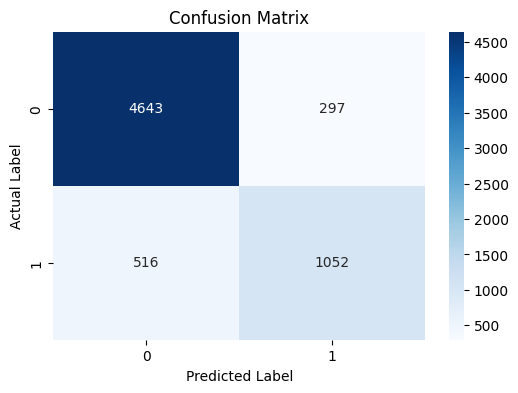

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

**Classification Report**

The classification report provides class-level performance metrics including:

- Precision
- Recall
- F1-Score
- Support

These metrics offer deeper insight into how well the model performs for each income category.

In [26]:
from sklearn.metrics import classification_report
print(
    classification_report(
    y_val,
    y_pred))

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4940
           1       0.78      0.67      0.72      1568

    accuracy                           0.88      6508
   macro avg       0.84      0.81      0.82      6508
weighted avg       0.87      0.88      0.87      6508



### Evaluation Summary

The baseline CatBoost model achieved an **accuracy of 87.51%**, indicating that the model correctly classified the majority of observations in the validation dataset.

The model obtained a **precision score of 77.98%**, meaning that when the model predicts an individual belongs to the high-income class (>50K), the prediction is correct approximately 78% of the time.

The **recall score of 67.09%** indicates that the model successfully identifies around 67% of all actual high-income individuals. While this demonstrates strong predictive capability, some high-income individuals are still misclassified as belonging to the low-income class.

The **F1-score of 72.13%** reflects a balanced trade-off between precision and recall for the positive class.

The model achieved an excellent **ROC-AUC score of 93.28%**, demonstrating a strong ability to distinguish between individuals earning less than or equal to $50K and those earning more than $50K.

The confusion matrix revealed that the model correctly classified:

- 4,643 low-income individuals (True Negatives)
- 1,052 high-income individuals (True Positives)

while producing:

- 297 False Positives
- 516 False Negatives

Overall, the baseline CatBoost model demonstrates strong predictive performance on the validation dataset and provides a solid foundation for further improvement through hyperparameter tuning and threshold optimization.

The testing dataset remains untouched and will be used only during the final evaluation stage to obtain unbiased performance estimates.

## Feature Importance Analysis

### Objective

The purpose of this section is to identify and analyze the features that contribute most to the CatBoost model's predictions.

Feature importance measures the relative contribution of each feature to the model's decision-making process. Features with higher importance scores have a greater influence on predicting whether an individual's income exceeds $50K.

Understanding feature importance improves model interpretability and provides insights into the factors most strongly associated with income levels.


After this analysis:

- The most influential features will be identified.
- Feature contributions will be visualized.
- The results will provide business and domain insights into income prediction.

In [27]:
# Extract feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': catboost_model.get_feature_importance()
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
feature_importance

,Feature,Importance
10,capital_gain,19.390482
7,relationship,17.814877
0,age,13.485925
12,hours_per_week,9.035534
6,occupation,7.714796
11,capital_loss,6.678044
5,marital_status,5.885935
4,education_num,5.339418
2,fnlwgt,3.902044
3,education,3.652698


In [28]:
feature_importance.head(10)

,Feature,Importance
10,capital_gain,19.390482
7,relationship,17.814877
0,age,13.485925
12,hours_per_week,9.035534
6,occupation,7.714796
11,capital_loss,6.678044
5,marital_status,5.885935
4,education_num,5.339418
2,fnlwgt,3.902044
3,education,3.652698


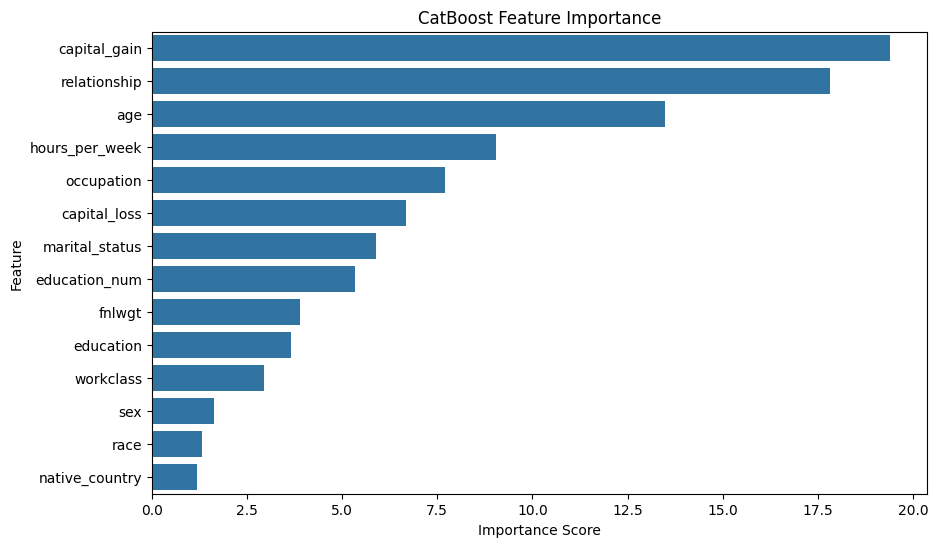

In [29]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)
plt.title('CatBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

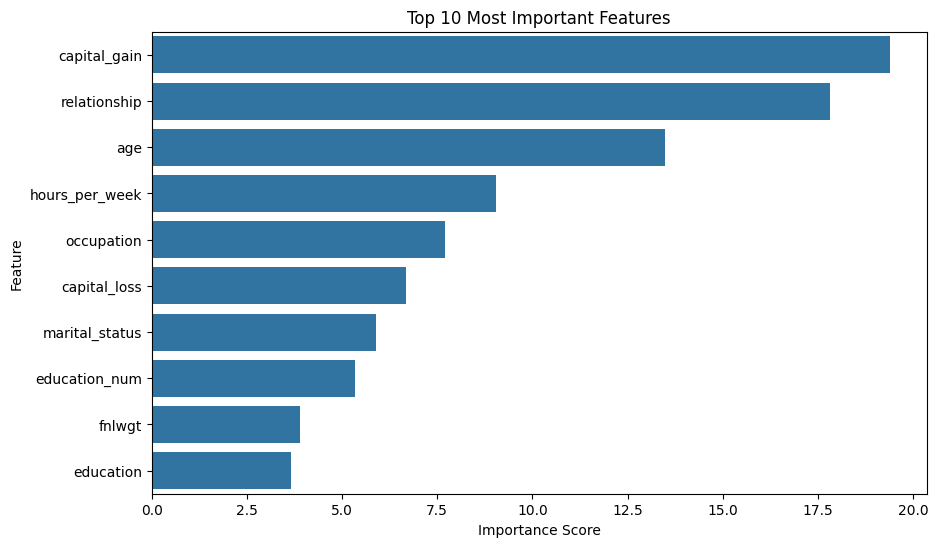

In [30]:
top_features = feature_importance.head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

### Feature Importance Summary

Feature importance analysis was performed to understand which variables had the greatest influence on the CatBoost model's income predictions.

The results indicate that **capital_gain** is the most influential feature, with an importance score of approximately **19.39**. This suggests that capital gains are strongly associated with membership in the high-income category.

The **relationship** feature emerged as the second most important predictor, highlighting the significant influence of household and family relationship status on income classification.

**Age** ranked as the third most important feature, indicating that income levels are strongly associated with career progression and accumulated work experience.

Work-related characteristics such as **hours_per_week**, **occupation**, and **marital_status** contributed substantially to the model's decisions, confirming that employment patterns and family circumstances are important determinants of income.

Educational attainment, represented by **education_num** and **education**, also contributed meaningfully to prediction performance, supporting the findings from the exploratory data analysis that higher educational levels are associated with increased earning potential.

Features such as **sex**, **race**, and **native_country** received relatively low importance scores, suggesting that they contribute less to the model's predictions compared to financial, occupational, demographic, and educational factors.

Overall, the feature importance analysis indicates that financial indicators, relationship status, age, employment characteristics, and education are the primary drivers of income prediction within the Adult Income dataset.

## Save Trained Model

### Objective

The purpose of this section is to save the trained CatBoost model for future use.

Saving the trained model allows it to be reused without retraining, which is useful for inference, deployment, and evaluation tasks.

The saved model artifact can later be loaded by external scripts or applications to generate predictions on new data.

After this step:

- The trained CatBoost model will be stored as a file.
- The model can be loaded and used for inference without retraining.
- The saved artifact will be used in subsequent project components such as model deployment and prediction pipelines.

In [31]:
# Save trained CatBoost model
catboost_model.save_model(
    'catboost_income_baseline_model.cbm')

In [32]:
import os
print(
    "Model file exists:",
    os.path.exists('catboost_income_baseline_model.cbm'))

Model file exists: True
